<a href="https://colab.research.google.com/github/vapena13/Examen2_RS_SVB_VAPG/blob/main/01_reproduccion_gpboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Reproducción de GPBoost
**Autor:** Viviana Andrea Peña González - Sebastian Velosa Bohorquez  
**Curso:** Percepción Remota  
**Herramientas:** Google Earth Engine + GPBoost



## 1. Introducción

Los modelos de boosting
suelen presentar limitaciones cuando los datos contienen dependencia espacial, ya que las observaciones cercanas geográficamente tienden a compartir características similares. GPBoost combina árboles de decisión con procesos gaussianos espaciales para modelar simultáneamente relaciones no lineales y autocorrelación espacial residual.

El objetivo de este ejercicio es reproducir un experimento de GPBoost con datos espaciales simulados y comparar su desempeño frente a un modelo Random Forest, que no modela explícitamente la autocorrelación espacial.

## 2. Fundamento teórico
$$
y = F(x) + b(s) + \epsilon
$$

La componente `F(X)` representa relaciones no lineales entre variables predictoras y la respuesta. La componente `b(s)` modela la dependencia espacial mediante un proceso gaussiano basado en coordenadas espaciales y `ϵ` como un error aleatorio.


In [1]:
# =========================================
# Instalación de librerías
# =========================================

!pip install gpboost lightgbm scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 16.5 MB/s eta 0:00:00


In [2]:
import gpboost as gpb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
import os
os.makedirs("outputs", exist_ok=True)

## 3. Generación de datos espaciales simulados

Para reproducir el ejercicio de Sigrist, se generó un conjunto de datos sintético con estructura espacial controlada. La simulación permite conocer de antemano los tres componentes que originan la variable respuesta:

*   Una **función media no lineal**.
*   Un **proceso gaussiano espacial**.
*   Un **término de error aleatorio**.

### Parámetros de Simulación

Se definieron **200 observaciones de entrenamiento** y una **cuadrícula regular de 50 × 50 puntos** para la evaluación espacial. Los parámetros clave del proceso gaussiano se establecieron de la siguiente manera:

*   **Varianza marginal del GP** $\sigma_1^2$: 0.35 (controla la magnitud del efecto espacial).
*   **Parámetro de rango espacial** ($\rho$): 0.1 (indica la escala de dependencia entre ubicaciones).
*   **Varianza del error** ($\sigma^2$): 0.1 (representa el ruido no explicado por la función media ni por el proceso espacial).

### Generación de Coordenadas y Matrices

Las **coordenadas de entrenamiento** se generaron aleatoriamente dentro de un dominio unitario [0,1] x [0,1], excluyendo el rectángulo superior derecho. Esta exclusión crea una **distribución espacial irregular**, útil para evaluar la capacidad del modelo en zonas con menor densidad de datos. Para el conjunto de prueba, se construyó una cuadrícula regular que cubre todo el dominio, lo que facilita la visualización de la superficie espacial simulada.

A partir de estas coordenadas, se calculó una **matriz de distancias euclidianas**, la cual se utilizó para definir una **matriz de covarianza exponencial**. Esta matriz modela cómo la similitud entre observaciones disminuye a medida que aumenta la distancia. Posteriormente, mediante la descomposición de Cholesky, se generó el **proceso gaussiano latente**, que es el componente espacial verdadero de la simulación.

### Variables Predictoras y Observadas

Se generaron dos **variables predictoras** aleatorias (`X`). Solo la primera variable (`X[:, 0]`) se usó para construir la **función media no lineal** (`F(X)`), mientras que la segunda actúa como una variable sin efecto real. Finalmente, la **variable respuesta** (`y`) se obtuvo sumando la función media, el proceso gaussiano espacial (`b(S)`) y el ruido aleatorio ($\epsilon$). Esta es la ecuación fundamental que se modela:

$$y = F(X) + b(S) + \epsilon$$

Este mismo procedimiento se aplicó al conjunto de prueba para obtener `y_test`, utilizando la función media evaluada sobre la cuadrícula, el proceso gaussiano latente correspondiente y un nuevo término de ruido aleatorio.

In [4]:
np.random.seed(1)
# Simulate Gaussian process: training and test data (the latter on a grid for visualization)
sigma2_1 = 0.35  # marginal variance of GP
rho = 0.1  # range parameter
sigma2 = 0.1  # error variance
n = 200  # number of training samples
nx = 50 # test data: number of grid points on each axis
# training locations (exclude upper right rectangle)
coords = np.column_stack(
  (np.random.uniform(size=1)/2, np.random.uniform(size=1)/2))
while coords.shape[0] < n:
  coord_i = np.random.uniform(size=2)
  if not (coord_i[0] >= 0.6 and coord_i[1] >= 0.6):
    coords = np.vstack((coords,coord_i))
# test locations (rectangular grid)
s_1 = np.ones(nx * nx)
s_2 = np.ones(nx * nx)
for i in range(nx):
  for j in range(nx):
    s_1[j * nx + i] = (i + 1) / nx
    s_2[i * nx + j] = (i + 1) / nx
coords_test = np.column_stack((s_1, s_2))
n_all = nx**2 + n # total number of data points
coords_all = np.vstack((coords_test,coords))
D = np.zeros((n_all, n_all))  # distance matrix
for i in range(0, n_all):
  for j in range(i + 1, n_all):
    D[i, j] = np.linalg.norm(coords_all[i, :] - coords_all[j, :])
    D[j, i] = D[i, j]
Sigma = sigma2_1 * np.exp(-D / rho) + np.diag(np.zeros(n_all) + 1e-10)
C = np.linalg.cholesky(Sigma)
b_all = C.dot(np.random.normal(size=n_all))
b_train = b_all[(nx*nx):n_all] # training data GP
# Mean function. Use two predictor variables of which only one has an effect for easy visualization
def f1d(x):
  return np.sin(3*np.pi*x) + (1 + 3 * np.maximum(np.zeros(len(x)),x-0.5)/(x-0.5)) - 3
X = np.random.rand(n, 2)
F_X_train = f1d(X[:, 0]) # mean
xi_train = np.sqrt(sigma2) * np.random.normal(size=n)  # simulate error term
y = F_X_train + b_train + xi_train  # observed data
# test data
x = np.linspace(0,1,nx**2)
x[x==0.5] = 0.5 + 1e-10
X_test = np.column_stack((x,np.zeros(nx**2)))
F_X_test = f1d(X_test[:, 0])
b_test = b_all[0:(nx**2)]
xi_test = np.sqrt(sigma2) * np.random.normal(size=(nx**2))
y_test = F_X_test + b_test + xi_test

### Guardar los datos simulados en archivos CSV

In [5]:
pd.DataFrame(X).to_csv('X_train.csv', index=False)
pd.DataFrame(y).to_csv('y_train.csv', index=False)
pd.DataFrame(coords).to_csv('coords_train.csv', index=False)
pd.DataFrame(X_test).to_csv('X_test.csv', index=False)
pd.DataFrame(y_test).to_csv('y_test.csv', index=False)
pd.DataFrame(coords_test).to_csv('coords_test.csv', index=False)

print("Datos guardados exitosamente en archivos CSV:")
print("- X_train.csv")
print("- y_train.csv")
print("- coords_train.csv")
print("- X_test.csv")
print("- y_test.csv")
print("- coords_test.csv")

Datos guardados exitosamente en archivos CSV:
- X_train.csv
- y_train.csv
- coords_train.csv
- X_test.csv
- y_test.csv
- coords_test.csv


## 4. Exploración y visualización de los datos

1.  **Función de Media**: Se observa la relación subyacente entre la primera variable predictora (`X_1`) y la respuesta, revelando un patrón no lineal que define la tendencia global de los datos.
2.  **Proceso Gaussiano Latente Verdadero **: Se evidencia la distribución del efecto espacial autocorrelacionado en la cuadrícula de prueba. Este componente muestra cómo los valores de la respuesta varían suavemente en el espacio debido a la dependencia geográfica.
3.  **Datos Observados vs. Variable Predictora**: Al comparar los datos observados (`y`) con la función de media (`F(X)`) en función de `X_1`, se visualiza cómo el efecto espacial y el ruido aleatorio causan desviaciones respecto a la tendencia pura.
4.  **Datos Observados y Ubicaciones**: Este gráfico de dispersión de los datos observados (`y`) en sus coordenadas (`s_1`, `s_2`) permite identificar patrones espaciales y la distribución general de la variable de respuesta.

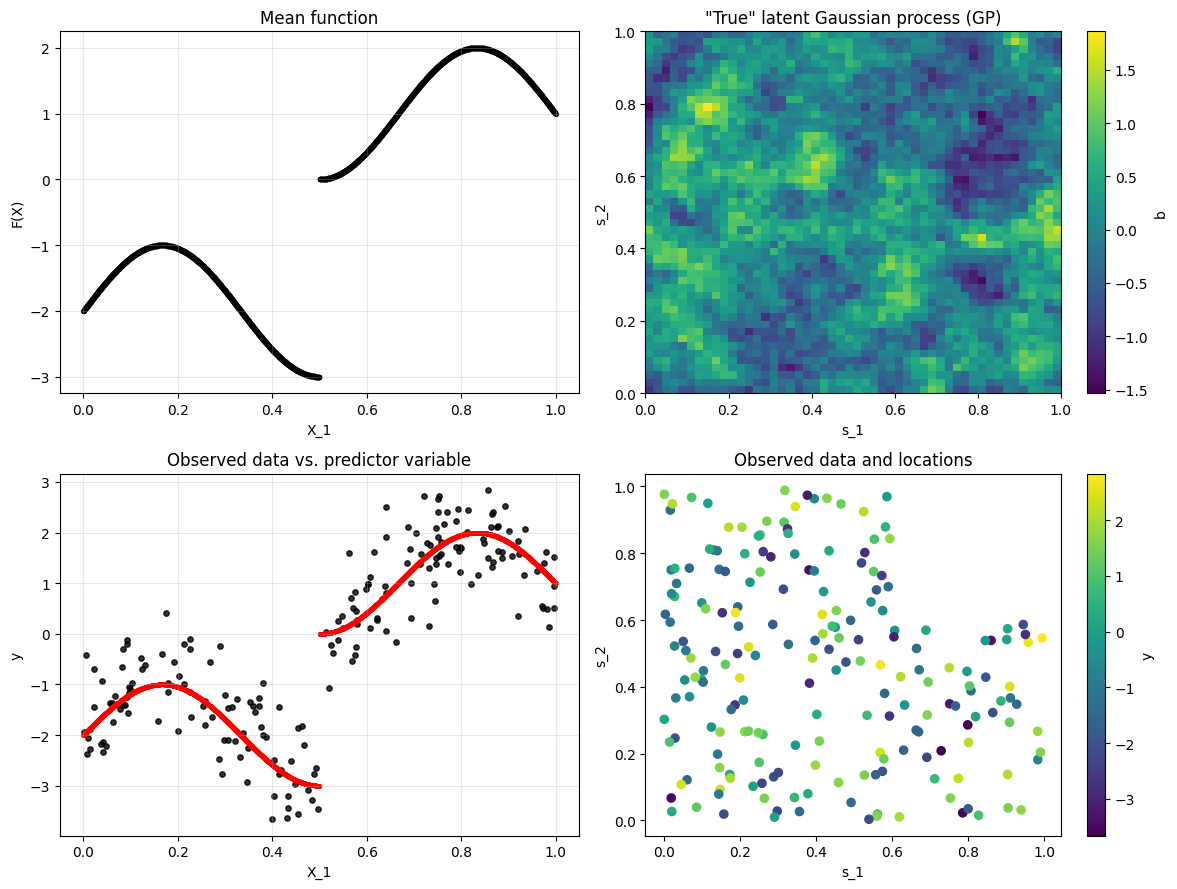

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Mean function
axes[0, 0].scatter(X_test[:, 0], F_X_test, s=8, color="black")
axes[0, 0].set_title("Mean function")
axes[0, 0].set_xlabel("X_1")
axes[0, 0].set_ylabel("F(X)")
axes[0, 0].grid(True, alpha=0.3)

# 2. True GP (using imshow as requested)
b_grid = b_test.reshape(nx, nx)
img = axes[0, 1].imshow(
    b_grid,
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="auto"
)
axes[0, 1].set_title('"True" latent Gaussian process (GP)')
axes[0, 1].set_xlabel("s_1")
axes[0, 1].set_ylabel("s_2")
fig.colorbar(img, ax=axes[0, 1], label="b")

# 3. Observed data vs predictor
axes[1, 0].scatter(X[:, 0], y, s=15, color="black", alpha=0.8)
axes[1, 0].scatter(X_test[:, 0], F_X_test, s=6, color="red")
axes[1, 0].set_title("Observed data vs. predictor variable")
axes[1, 0].set_xlabel("X_1")
axes[1, 0].set_ylabel("y")
axes[1, 0].grid(True, alpha=0.3)

# 4. Observed data and locations
sc2 = axes[1, 1].scatter(
    coords[:, 0],
    coords[:, 1],
    c=y,
    s=35
)
axes[1, 1].set_title("Observed data and locations")
axes[1, 1].set_xlabel("s_1")
axes[1, 1].set_ylabel("s_2")
fig.colorbar(sc2, ax=axes[1, 1], label="y")

plt.tight_layout()
plt.show();

## 5. Implementación del Modelo GPBoost
Para la implementación del modelo GPBoost, se definen los parámetros del modelo, el conjunto de datos de entrenamiento, se entrena el modelo y se realizan las predicciones para evaluar su rendimiento inicial.


1.  **Creación del Modelo GP**:

    ```python
    gp_model = gpb.GPModel(
        gp_coords=coords,
        cov_function="exponential"
    )
    ```

    *   `gp_coords`: Se le proporcionan las coordenadas espaciales (`coords`) de los datos de entrenamiento.
    *   `cov_function`: Se especifica la función de covarianza para el Proceso Gaussiano. En este caso, se utiliza la función "exponential" (exponencial), que es una elección común que asume que la correlación espacial disminuye exponencialmente con la distancia.

2.  **Preparación de los Datos de Entrenamiento**:

    ```python
    data_train = gpb.Dataset(X, y)
    ```

    *   Se crea un objeto `Dataset` de GPBoost, que encapsula las variables predictoras `X` y la variable de respuesta `y` del conjunto de entrenamiento.

3.  **Definición de Parámetros**:

    ```python
    params = {
        "objective": "regression_l2",
        "learning_rate": 0.01,
        "max_depth": 3,
        "min_data_in_leaf": 10,
        "num_leaves": 2**10,
        "verbose": 0
    }
    ```

    *   `objective`: se indica que el modelo realizará una regresión utilizando el error cuadrático medio (L2) como función objetivo.
    *   `learning_rate`: La tasa de aprendizaje se asigna un valor bajo para procurar no tener sobreajuste.
    *   `max_depth`: La profundidad máxima de los árboles de decisión individuales con un valor de `3` significa árboles no muy profundos.
    *   `min_data_in_leaf`: El número mínimo de ejemplos de datos requeridos para formar un nodo hoja. Un valor de `10` ayuda a evitar que los árboles se ajusten demasiado a ruidos específicos en los datos.
    *   `num_leaves`: El número máximo de hojas en un árbol. `2**10` es un valor relativamente alto, pero `max_depth` limita la profundidad, por lo que el número real de hojas podría ser menor.
    *   `verbose`: Se establece en `0` para suprimir la salida detallada durante el entrenamiento.

4.  **Entrenamiento del Modelo (`gpb.train`)**:

    ```python
    bst = gpb.train(
        params=params,
        train_set=data_train,
        gp_model=gp_model,
        num_boost_round=247
    )
    ```

    *   Se entrena el modelo `bst` (boosting) con los parámetros definidos, el conjunto de datos de entrenamiento y el modelo GP. `num_boost_round=247` especifica el número total de iteraciones de boosting (número de árboles).

5.  **Resumen del Modelo GP:**

    ```python
    gp_model.summary()
    ```

    *   Muestra un resumen de los parámetros estimados para el modelo GP (varianzas y rango).

6.  **Predicción (`bst.predict`)**:

    ```python
    pred = bst.predict(
        data=X_test,
        gp_coords_pred=coords_test,
        predict_var=True,
        pred_latent=True
    )

    pred_resp = bst.predict(
        data=X_test,
        gp_coords_pred=coords_test,
        predict_var=False,
        pred_latent=False
    )

    y_pred_gpboost = pred_resp["response_mean"]
    ```

    *   Se realizan dos tipos de predicciones en el conjunto de prueba (`X_test`, `coords_test`):
        *   `pred`: Realiza una predicción completa incluyendo la varianza (`predict_var=True`) y el efecto latente del GP (`pred_latent=True`). Esto permite inspeccionar las diferentes componentes de la predicción.
        *   `pred_resp`: Realiza una predicción solo de la media de la respuesta (`pred_latent=False`, `predict_var=False`), que es el valor final de interés para la evaluación.
    *   `y_pred_gpboost` almacena la media de la respuesta predicha.

7.  **Cálculo de la Métrica Inicial (MSE)**:

    ```python
    mse_gpboost = np.mean((y_pred_gpboost - y_test) ** 2)
    print("MSE GPBoost:", mse_gpboost)
    ```

    *   Se calcula el Error Cuadrático Medio (MSE) comparando las predicciones del modelo (`y_pred_gpboost`) con los valores verdaderos del conjunto de prueba (`y_test`).

In [7]:
gp_model = gpb.GPModel(
    gp_coords=coords,
    cov_function="exponential"
)

data_train = gpb.Dataset(X, y)

params = {
    "objective": "regression_l2",
    "learning_rate": 0.01,
    "max_depth": 3,
    "min_data_in_leaf": 10,
    "num_leaves": 2**10,
    "verbose": 0
}

bst = gpb.train(
    params=params,
    train_set=data_train,
    gp_model=gp_model,
    num_boost_round=247
)

gp_model.summary()

pred = bst.predict(
    data=X_test,
    gp_coords_pred=coords_test,
    predict_var=True,
    pred_latent=True
)

# pred["fixed_effect"]: predictions from the tree ensemble
# pred["random_effect_mean"]: predicted means of the GP model
# pred["random_effect_cov"]: predicted variances/covariances of the GP model

pred_resp = bst.predict(
    data=X_test,
    gp_coords_pred=coords_test,
    predict_var=False,
    pred_latent=False
)

y_pred_gpboost = pred_resp["response_mean"]

mse_gpboost = np.mean((y_pred_gpboost - y_test) ** 2)
print("MSE GPBoost:", mse_gpboost)

Model summary:
Nb. observations: 200
Covariance parameters (random effects):
           Param.  Std. err.
Error_var  0.0000     0.0198
GP_var     0.2913     0.0452
GP_range   0.0576     0.0132
MSE GPBoost: 0.36877096054821945


### 5.1. Interpretación de los Resultados Iniciales del Modelo GPBoost

Después de entrenar el modelo GPBoost con los parámetros iniciales, obtenemos el siguiente resumen y métrica:

1.  **Resumen del Modelo GP (`gp_model.summary()`)**:

    ```
    =====================================================
    Model summary:
    Nb. observations: 200
    Covariance parameters (random effects):
               Param.  Std. err.
    Error_var  0.0000     0.0198
    GP_var     0.2913     0.0452
    GP_range   0.0576     0.0132
    =====================================================
    ```

    * El modelo fue entrenado con `200` observaciones, coincidiendo con el tamaño definido en la simulación. La varianza estimada del proceso gaussiano fue `0.2913`, valor cercano a la varianza espacial simulada de `0.35`. Esto indica que el modelo logró identificar una componente espacial relevante en los datos.
    * El parámetro de rango estimado fue `0.0576`, menor que el valor simulado de `0.1`. Esta diferencia puede deberse a que parte de la variabilidad espacial fue capturada por la componente de boosting, dejando al proceso gaussiano una estructura residual de menor alcance espacial.

2.  **MSE GPBoost Inicial**:

    ```
    MSE GPBoost: 0.36877096054821945
    ```

    *  Este valor se toma como línea base para comparar el efecto del ajuste de hiperparámetros y la comparación posterior con Random Forest.

/tmp/ipykernel_1270/3548869680.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  _ = shap.summary_plot(shap_values, X, show=False) # Let SHAP create and plot on a figure


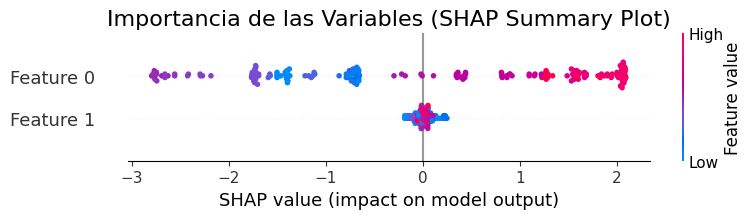

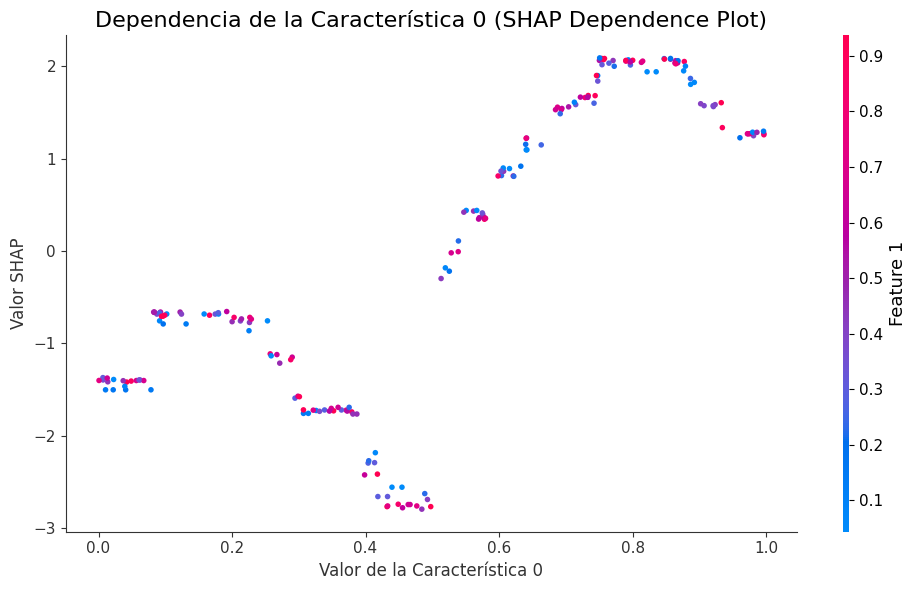

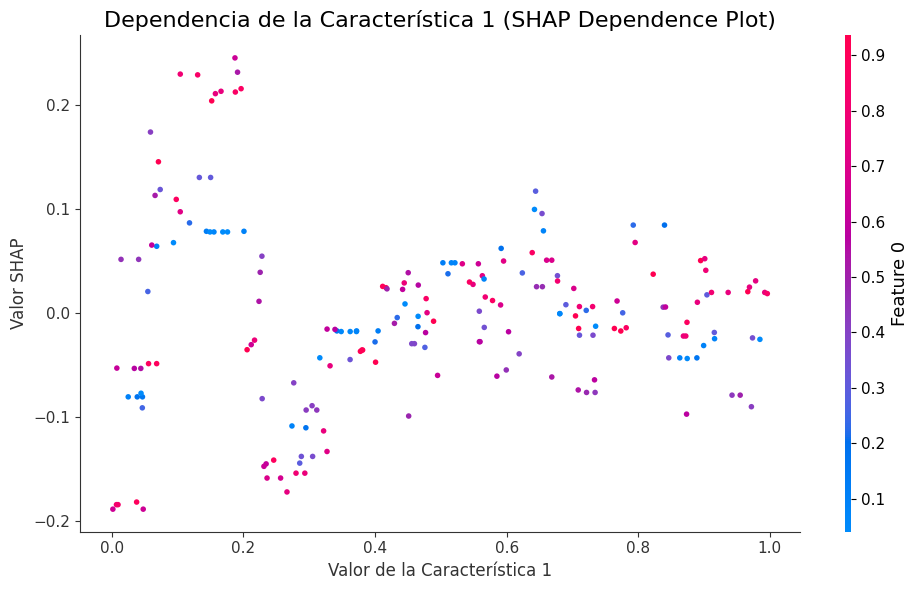

In [8]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Calculate SHAP values
explainer = shap.TreeExplainer(bst)
shap_values = explainer.shap_values(X)

# --- SHAP Summary Plot ---
# shap.summary_plot creates its own figure and plots on it. It does not return the figure object itself.
_ = shap.summary_plot(shap_values, X, show=False) # Let SHAP create and plot on a figure
summary_plot_fig = plt.gcf() # Get a reference to the figure SHAP just created
summary_plot_ax = summary_plot_fig.gca() # Now we can get its axes
summary_plot_ax.set_title("Importancia de las Variables (SHAP Summary Plot)", fontsize=16)
summary_plot_fig.tight_layout()
plt.show(); # Display the figure
plt.close(summary_plot_fig) # Close the specific figure

# --- SHAP Dependence Plot for Feature 0 ---
fig_dep_0, ax_dep_0 = plt.subplots(figsize=(10, 6)) # Create figure and axes
_ = shap.dependence_plot("Feature 0", shap_values, X, show=False, ax=ax_dep_0)
ax_dep_0.set_title("Dependencia de la Característica 0 (SHAP Dependence Plot)", fontsize=16)
ax_dep_0.set_xlabel("Valor de la Característica 0", fontsize=12)
ax_dep_0.set_ylabel("Valor SHAP", fontsize=12)
fig_dep_0.tight_layout()
plt.show();
plt.close(fig_dep_0) # Close the figure

# --- SHAP Dependence Plot for Feature 1 ---
fig_dep_1, ax_dep_1 = plt.subplots(figsize=(10, 6)) # Create figure and axes
_ = shap.dependence_plot("Feature 1", shap_values, X, show=False, ax=ax_dep_1)
ax_dep_1.set_title("Dependencia de la Característica 1 (SHAP Dependence Plot)", fontsize=16)
ax_dep_1.set_xlabel("Valor de la Característica 1", fontsize=12)
ax_dep_1.set_ylabel("Valor SHAP", fontsize=12)
fig_dep_1.tight_layout()
plt.show();
plt.close(fig_dep_1) # Close the figure

# Final safeguard to ensure nothing else is displayed
None

La gráfica SHAP muestra que la primera variable predictora concentra la mayor contribución al modelo. Este resultado es coherente con la simulación, ya que la función media fue construida únicamente a partir de X_1. La segunda variable fue incluida como predictor sin efecto real, por lo que su importancia esperada es menor.

## 6. Ajuste de Hiperparámetros con Grid Search

El ajuste de hiperparámetros es un paso crucial para optimizar el rendimiento del modelo. En este caso, se ha utilizado una estrategia de búsqueda de cuadrícula aleatoria (`grid_search_tune_parameters`) para explorar combinaciones de hiperparámetros y encontrar la que minimiza el error de validación.

1.  **Parámetros Evaluados**:

    *   `learning_rate`: [1, 0.1, 0.01] – La tasa de aprendizaje, que controla el tamaño del paso en cada iteración del boosting.
    *   `min_data_in_leaf`: [1, 10, 100] – El número mínimo de datos requeridos para formar un nodo hoja, ayudando a controlar el sobreajuste.
    *   `max_depth`: [1, 3, 5, 10] – La profundidad máxima de cada árbol de decisión individual, también una medida de complejidad del modelo.

    Se mantuvieron fijos otros parámetros como `objective='regression_l2'` (función objetivo de regresión) y `num_leaves=2**17` (un número suficientemente grande de hojas para no ser una restricción principal, dejando que `max_depth` controle la complejidad del árbol).

2.  **Proceso de Búsqueda de Cuadrícula**:

    *   Se realizaron `20` pruebas aleatorias de un total de `36` combinaciones posibles de parámetros. Este enfoque es más eficiente que una búsqueda de cuadrícula exhaustiva cuando el espacio de parámetros es grande.
    *   Se utilizó una validación cruzada de `4` pliegues (`nfold=4`) para evaluar cada combinación de parámetros y obtener una estimación robusta del rendimiento del modelo.
    *   Se aplicó `early_stopping_rounds=5`, lo que significa que el entrenamiento se detiene si el rendimiento en el conjunto de validación no mejora durante 5 rondas consecutivas, evitando el sobreajuste al número de rondas de boosting.
    *   La métrica utilizada para evaluar el rendimiento fue el error cuadrático medio (`metric='l2'`).

In [9]:
gp_model = gpb.GPModel(gp_coords=coords, cov_function="exponential")
data_train = gpb.Dataset(X, y)
# Candidate parameter grid
param_grid = {'learning_rate': [1,0.1,0.01],
              'min_data_in_leaf': [1,10,100],
              'max_depth': [1,3,5,10]}
# Other parameters not contained in the grid of tuning parameters
params = { 'objective': 'regression_l2', 'verbose': 0,
           'num_leaves': 2**17 }
opt_params = gpb.grid_search_tune_parameters(
  param_grid=param_grid, params=params,
  num_try_random=20, nfold=4,
  gp_model=gp_model, train_set=data_train,
  verbose_eval=1,
  num_boost_round=1000, early_stopping_rounds=5,
  seed=1, metric='l2')
# 'metric' was called 'metrics' in earlier versions of gpboost
print("Best number of iterations: " + str(opt_params['best_iter']))
print("Best score: " + str(opt_params['best_score']))
print("Best parameters: " + str(opt_params['best_params']))

Starting random grid search with 20 trials out of 36 parameter combinations 
Trying parameter combination 1 of 20: {'learning_rate': np.float64(1.0), 'min_data_in_leaf': np.int64(10), 'max_depth': np.int64(10)}
***** New best test score (l2 = 0.5542920902957914) found for the following parameter combination:
{'learning_rate': np.float64(1.0), 'min_data_in_leaf': np.int64(10), 'max_depth': np.int64(10), 'num_boost_round': np.int64(2)}
Trying parameter combination 2 of 20: {'learning_rate': np.float64(0.1), 'min_data_in_leaf': np.int64(100), 'max_depth': np.int64(10)}
Trying parameter combination 3 of 20: {'learning_rate': np.float64(0.1), 'min_data_in_leaf': np.int64(1), 'max_depth': np.int64(10)}
Trying parameter combination 4 of 20: {'learning_rate': np.float64(1.0), 'min_data_in_leaf': np.int64(10), 'max_depth': np.int64(1)}
Trying parameter combination 5 of 20: {'learning_rate': np.float64(0.1), 'min_data_in_leaf': np.int64(1), 'max_depth': np.int64(5)}
***** New best test score (l2



3.  **Mejor Combinación de Parámetros**:

    Los resultados de la búsqueda de cuadrícula indicaron la siguiente mejor combinación de parámetros:

    ```
    Best number of iterations: 119
    Best score: 0.32974626311021665
    Best parameters: {'learning_rate': np.float64(0.1), 'min_data_in_leaf': np.int64(10), 'max_depth': np.int64(1)}
    ```

    *   **`learning_rate: 0.1`**: Una tasa de aprendizaje moderada.
    *   **`min_data_in_leaf: 10`**: Un número de datos por hoja que ayuda a generalizar.
    *   **`max_depth: 1`**: Árboles muy poco profundos (similares a 'stumps'), lo que sugiere que el modelo de boosting, junto con el GP, es capaz de capturar la complejidad con componentes sencillos.
    *   **`Best number of iterations: 119`**: El número óptimo de rondas de boosting.
    *   **`Best score: 0.3297`**: El mejor valor de MSE (l2) obtenido en el conjunto de validación.

4.  **Reentrenamiento del Modelo con los Mejores Parámetros**:

Una vez identificada la mejor combinación de hiperparámetros mediante la búsqueda de cuadrícula, se procede a reentrenar el modelo GPBoost final (`bst_tuned`) utilizando estos valores óptimos. Este paso asegura que el modelo se beneficie de la configuración que minimizó el error en el proceso de validación.

Los parámetros utilizados para el reentrenamiento son:

*   `learning_rate = 0.1`
*   `min_data_in_leaf = 10`
*   `max_depth = 1`
*   `num_boost_round = 119` (el número óptimo de iteraciones).

La configuración resultante (árboles poco profundos combinados con el componente espacial gaussiano) demostró ser suficiente para capturar la estructura no lineal y la autocorrelación espacial en los datos simulados sin introducir una complejidad excesiva.



In [10]:
best_params = {
    "objective": "regression_l2",
    "learning_rate": 0.1,
    "min_data_in_leaf": 10,
    "max_depth": 1,
    "verbose": 0
}

gp_model_tuned = gpb.GPModel(
    gp_coords=coords,
    cov_function="exponential"
)

data_train = gpb.Dataset(X, y)

bst_tuned = gpb.train(
    params=best_params,
    train_set=data_train,
    gp_model=gp_model_tuned,
    num_boost_round=119
)

pred_tuned = bst_tuned.predict(
    data=X_test,
    gp_coords_pred=coords_test,
    predict_var=False,
    pred_latent=False
)

y_pred_tuned = pred_tuned["response_mean"]

mse_tuned = np.mean((y_pred_tuned - y_test) ** 2)
rmse_tuned = np.sqrt(mse_tuned)

print("MSE GPBoost ajustado:", mse_tuned)
print("RMSE GPBoost ajustado:", rmse_tuned)

MSE GPBoost ajustado: 0.3404539974780668
RMSE GPBoost ajustado: 0.5834843592403028


## 7. Comparación con un Modelo No Espacial: Random Forest

Para evaluar la contribución del componente espacial de GPBoost, se entrenó un modelo Random Forest con las mismas variables predictoras. Random Forest puede capturar relaciones no lineales, pero no incluye un proceso explícito para modelar autocorrelación espacial residual.

| Modelo | RMSE | R² |
|:--------------|----------|----------|
| GPBoost | 0.583484 | 0.873735 |
| Random Forest | 0.716060 | 0.809838 |

Los resultados muestran que GPBoost obtuvo menor RMSE y mayor R² que Random Forest. En particular, GPBoost alcanzó un RMSE de 0.583 y un R² de 0.874, mientras que Random Forest obtuvo un RMSE de 0.716 y un R² de 0.810.

Esta diferencia indica que, en datos con dependencia espacial simulada, la inclusión del proceso gaussiano mejora la capacidad predictiva del modelo. El resultado es consistente con la estructura de los datos, ya que la variable respuesta fue generada incorporando explícitamente un componente espacial.

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=1
)

rf.fit(X, y)

y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("MSE Random Forest:", mse_rf)
print("RMSE Random Forest:", rmse_rf)

MSE Random Forest: 0.5127418635687712
RMSE Random Forest: 0.7160599580822622


In [12]:
comparison_df = pd.DataFrame({
    "Modelo": ["GPBoost", "Random Forest"],
    "RMSE": [rmse_tuned, rmse_rf],
    "R2": [r2_score(y_test, y_pred_tuned), r2_score(y_test, y_pred_rf)],
    "MSE": [mse_tuned, mse_rf]
})

display(comparison_df)

comparison_df.to_csv("outputs/tabla_comparacion_modelos.csv", index=False)

,Modelo,RMSE,R2,MSE
0,GPBoost,0.583484,0.873735,0.340454
1,Random Forest,0.716060,0.809838,0.512742


## 8. Evaluación espacial de predicciones y residuales

Además de las métricas globales, se evaluó el comportamiento espacial de los modelos. Para ello se visualizó la componente espacial estimada por GPBoost, los errores de predicción y la comparación entre la superficie verdadera y las superficies predichas por GPBoost y Random Forest.

La componente espacial estimada por GPBoost permite observar qué parte de la variabilidad residual fue atribuida al proceso gaussiano. Este análisis es importante porque el objetivo del modelo no es solo reducir el error promedio, sino también representar adecuadamente la estructura espacial de los datos.


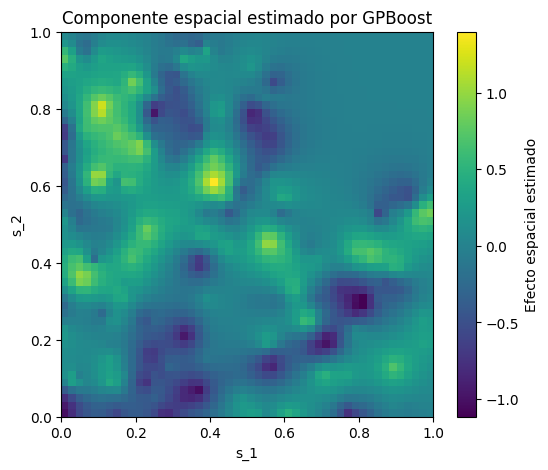

In [13]:
# Parte espacial estimada por GPBoost
pred_latent = bst_tuned.predict(
    data=X_test,
    gp_coords_pred=coords_test,
    predict_var=True,
    pred_latent=True
)

gp_random_effect = pred_latent["random_effect_mean"]

plt.figure(figsize=(6, 5))
img = plt.imshow(
    gp_random_effect.reshape(nx, nx),
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="auto"
)
plt.colorbar(img, label="Efecto espacial estimado")
plt.title("Componente espacial estimado por GPBoost")
plt.xlabel("s_1")
plt.ylabel("s_2")
plt.show();

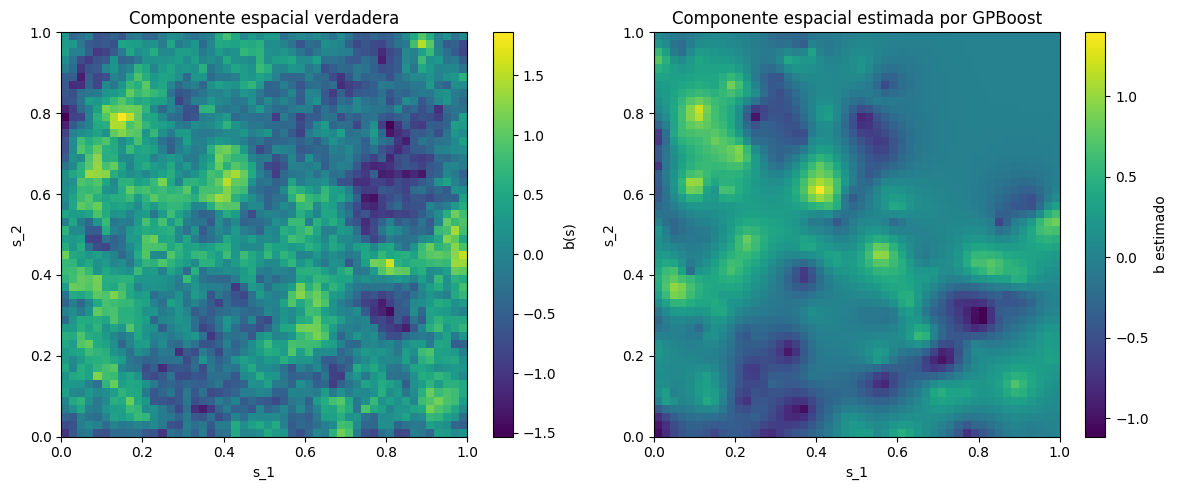

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

img1 = axes[0].imshow(
    b_test.reshape(nx, nx),
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="auto"
)
axes[0].set_title("Componente espacial verdadera")
axes[0].set_xlabel("s_1")
axes[0].set_ylabel("s_2")
fig.colorbar(img1, ax=axes[0], label="b(s)")

img2 = axes[1].imshow(
    gp_random_effect.reshape(nx, nx),
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="auto"
)
axes[1].set_title("Componente espacial estimada por GPBoost")
axes[1].set_xlabel("s_1")
axes[1].set_ylabel("s_2")
fig.colorbar(img2, ax=axes[1], label="b estimado")

plt.tight_layout()
plt.savefig("outputs/componente_espacial_verdadera_vs_estimada.png", dpi=300, bbox_inches="tight")
plt.show()

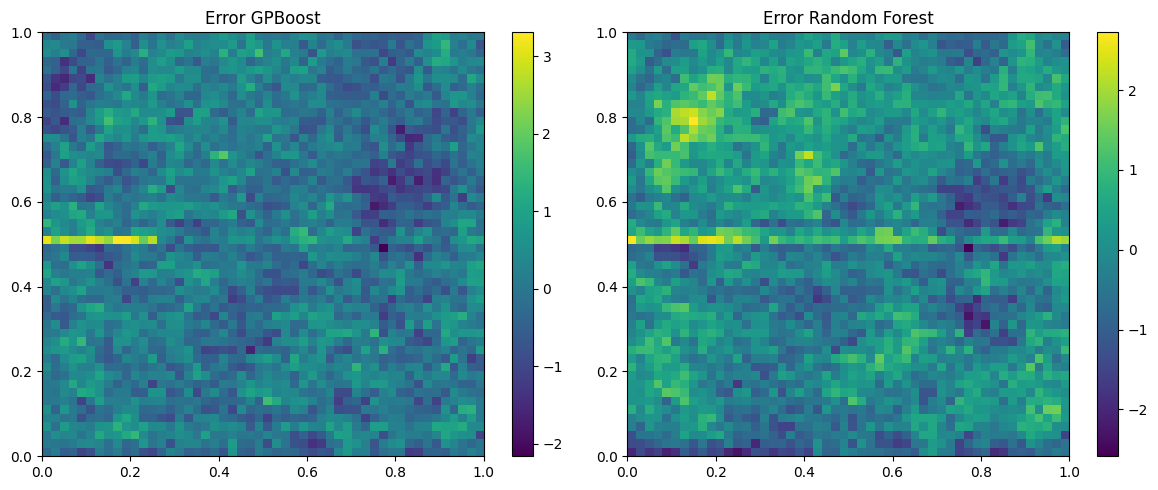

In [15]:
error_gpboost = y_test - y_pred_tuned
error_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

img1 = axes[0].imshow(
    error_gpboost.reshape(nx, nx),
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="auto"
)
axes[0].set_title("Error GPBoost")
fig.colorbar(img1, ax=axes[0])

img2 = axes[1].imshow(
    error_rf.reshape(nx, nx),
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="auto"
)
axes[1].set_title("Error Random Forest")
fig.colorbar(img2, ax=axes[1])

plt.tight_layout()
plt.show();

Los mapas muestran que Random Forest logra aproximar la tendencia general de la función media, pero presenta menor capacidad para recuperar patrones espaciales locales. GPBoost, en cambio, reproduce mejor la estructura espacial de la respuesta, ya que combina la componente de árboles con el proceso gaussiano definido sobre las coordenadas.

Los residuales también muestran diferencias entre modelos. En GPBoost, los errores presentan menor estructura espacial visible, mientras que en Random Forest persisten patrones espaciales más marcados. Esto sugiere que GPBoost logra absorber parte de la autocorrelación espacial que Random Forest deja en los residuales.

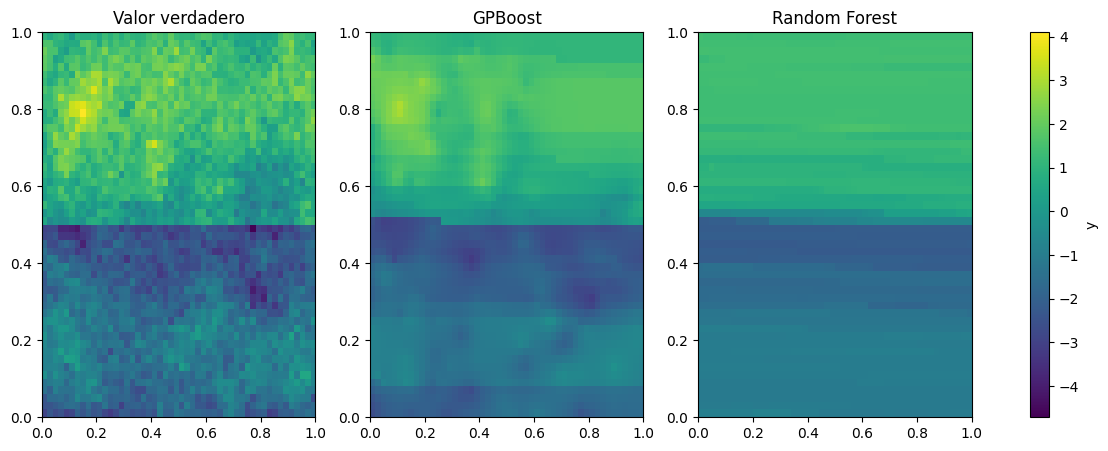

In [16]:
vmin = min(y_pred_tuned.min(), y_pred_rf.min(), y_test.min())
vmax = max(y_pred_tuned.max(), y_pred_rf.max(), y_test.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, values, title in zip(
    axes,
    [y_test, y_pred_tuned, y_pred_rf],
    ["Valor verdadero", "GPBoost", "Random Forest"]
):
    img = ax.imshow(
        values.reshape(nx, nx),
        origin="lower",
        extent=[0, 1, 0, 1],
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(title)

fig.colorbar(img, ax=axes.ravel().tolist(), label="y")
plt.show();

## 9. Análisis de Métricas Finales

Si bien métricas globales como RMSE y R² ofrecen una evaluación general del rendimiento del modelo, en el contexto de datos espaciales, el análisis de **métricas locales** es crucial. Este enfoque permite comprender el comportamiento del modelo en diversas ubicaciones geográficas e identificar patrones espaciales residuales en los errores de predicción.

El análisis local es fundamental para:

*   **Identificar patrones de error espaciales**: Detectar si el modelo exhibe un sesgo sistemático (sobrestimación o subestimación) en regiones específicas, lo que podría señalar la presencia de efectos espaciales no capturados.
*   **Evaluar la fidelidad de la estructura espacial**: Confirmar si las superficies de predicción del modelo son coherentes con la autocorrelación espacial inherente a los datos reales.
*   **Diagnosticar limitaciones del modelo**: Revelar áreas donde el rendimiento del modelo es deficiente, orientando futuras mejoras o ajustes en su formulación espacial.

En las siguientes visualizaciones, exploraremos los residuales espaciales y las superficies predichas para los modelos GPBoost y Random Forest, facilitando una comparación detallada de su desempeño local.

In [17]:
from sklearn.metrics import r2_score

print("===== GPBoost =====")
print("RMSE:", rmse_tuned)
print("R2:", r2_score(y_test, y_pred_tuned))

print("\n===== Random Forest =====")
print("RMSE:", rmse_rf)
print("R2:", r2_score(y_test, y_pred_rf))

===== GPBoost =====
RMSE: 0.5834843592403028
R2: 0.8737352094280011

===== Random Forest =====
RMSE: 0.7160599580822622
R2: 0.8098384965352678


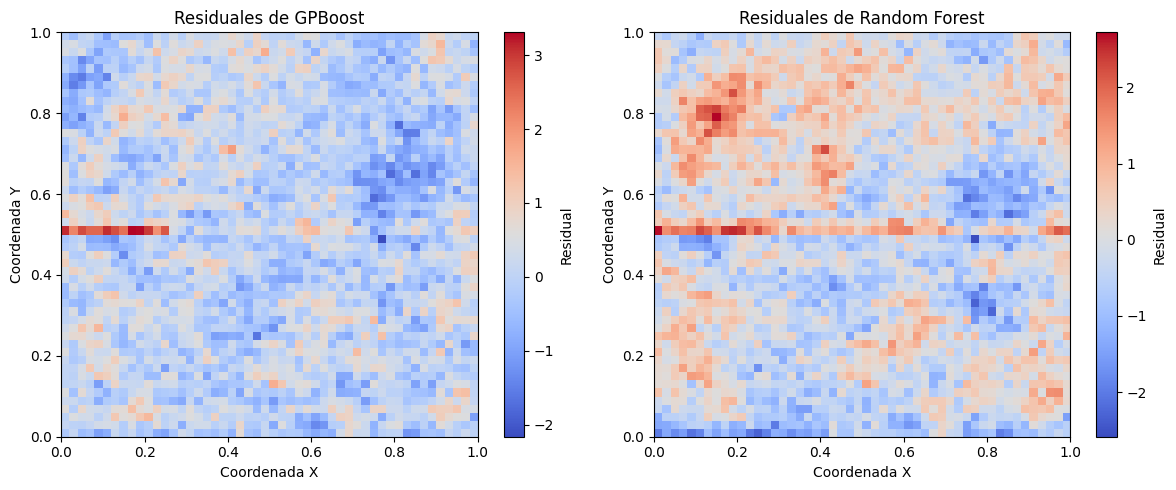

In [18]:
res_gp = y_test - y_pred_tuned
res_rf = y_test - y_pred_rf

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
img1 = plt.imshow(
    res_gp.reshape(nx, nx),
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="auto",
    cmap='coolwarm'
)
plt.colorbar(img1, label="Residual")
plt.title("Residuales de GPBoost")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")

plt.subplot(1, 2, 2)
img2 = plt.imshow(|
    res_rf.reshape(nx, nx),
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="auto",
    cmap='coolwarm'
)
plt.colorbar(img2, label="Residual")
plt.title("Residuales de Random Forest")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")

plt.tight_layout()
plt.show();

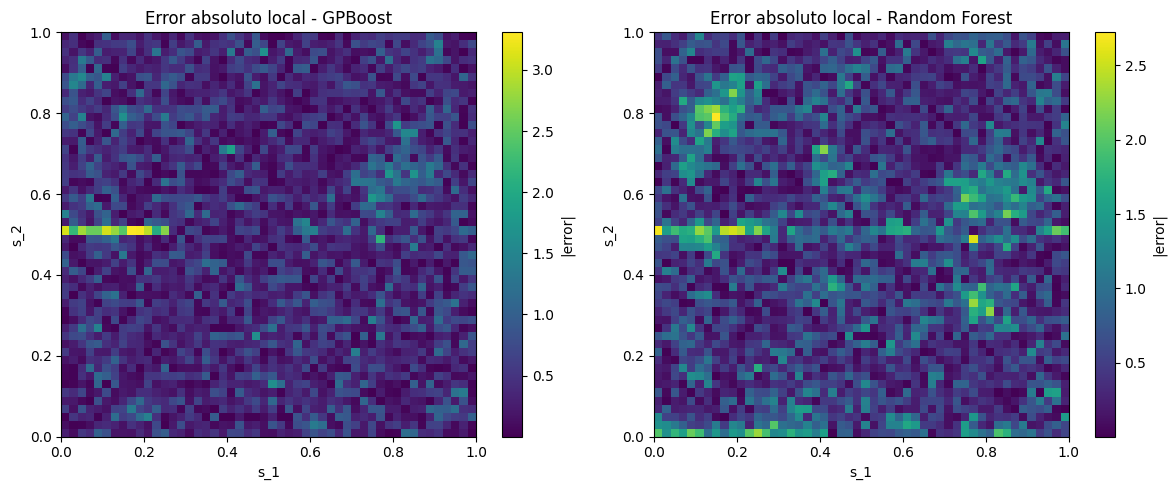

In [19]:
ae_gpboost = np.abs(y_test - y_pred_tuned)
ae_rf = np.abs(y_test - y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

img1 = axes[0].imshow(
    ae_gpboost.reshape(nx, nx),
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="auto"
)
axes[0].set_title("Error absoluto local - GPBoost")
axes[0].set_xlabel("s_1")
axes[0].set_ylabel("s_2")
fig.colorbar(img1, ax=axes[0], label="|error|")

img2 = axes[1].imshow(
    ae_rf.reshape(nx, nx),
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="auto"
)
axes[1].set_title("Error absoluto local - Random Forest")
axes[1].set_xlabel("s_1")
axes[1].set_ylabel("s_2")
fig.colorbar(img2, ax=axes[1], label="|error|")

plt.tight_layout()
plt.savefig("outputs/error_absoluto_local_gpboost_rf.png", dpi=300, bbox_inches="tight")
plt.show()

[texto del enlace](https://)### Análisis del Error Absoluto Local

La visualización del error absoluto local para ambos modelos, GPBoost y Random Forest, revela diferencias clave en su capacidad para manejar la heterogeneidad espacial. Se observa que el modelo GPBoost exhibe, en general, un error absoluto menor y más distribuido uniformemente a lo largo del dominio espacial. Esto sugiere que el componente gaussiano del GPBoost logra capturar y modelar eficazmente la autocorrelación espacial inherente a los datos, reduciendo la magnitud de los errores en diversas ubicaciones.

En contraste, el mapa de error absoluto de Random Forest tiende a mostrar regiones con errores más pronunciados y patrones espaciales de error más marcados. Esta observación refuerza la hipótesis de que, al no incorporar explícitamente una estructura espacial en su formulación, Random Forest lucha por ajustarse a las variaciones espaciales finas, dejando residuales más grandes y estructurados. La comparación visual de estos mapas subraya la ventaja de GPBoost en escenarios donde la dependencia espacial es un factor significativo en la generación de los datos.

In [20]:
data = {
    'Modelo': ['GPBoost', 'Random Forest'],
    'RMSE': [rmse_tuned, rmse_rf],
    'R2': [r2_score(y_test, y_pred_tuned), r2_score(y_test, y_pred_rf)]
}

df_metrics = pd.DataFrame(data)
print(df_metrics.to_markdown(index=False))

| Modelo        |     RMSE |       R2 |
|:--------------|---------:|---------:|
| GPBoost       | 0.583484 | 0.873735 |
| Random Forest | 0.71606  | 0.809838 |


In [21]:
model_save_path = 'outputs/gpboost_model_tuned.json'
bst_tuned.save_model(model_save_path)
print(f"Modelo GPBoost ajustado guardado en: {model_save_path}")

Modelo GPBoost ajustado guardado en: outputs/gpboost_model_tuned.json


In [22]:
import joblib

rf_save_path = 'outputs/random_forest_model.joblib'
joblib.dump(rf, rf_save_path)
print(f"Modelo Random Forest guardado en: {rf_save_path}")

Modelo Random Forest guardado en: outputs/random_forest_model.joblib


##  Conclusiones
Los mapas muestran que Random Forest logra aproximar la tendencia general de la función media, pero presenta menor capacidad para recuperar patrones espaciales locales. GPBoost, en cambio, reproduce mejor la estructura espacial de la respuesta, ya que combina la componente de árboles con el proceso gaussiano definido sobre las coordenadas.

Los residuales también muestran diferencias entre modelos. En GPBoost, los errores presentan menor estructura espacial visible, mientras que en Random Forest persisten patrones espaciales más marcados. Esto sugiere que GPBoost logra absorber parte de la autocorrelación espacial que Random Forest deja en los residuales.

La reproducción permitió evaluar GPBoost en un escenario espacial controlado, donde la variable respuesta fue generada como la suma de una función media no lineal, un proceso gaussiano espacial y un término de error aleatorio.

El modelo GPBoost ajustado obtuvo menor error que Random Forest, con RMSE = 0.583 y R² = 0.874, frente a RMSE = 0.716 y R² = 0.810 en Random Forest. Esta diferencia se explica por la capacidad de GPBoost para incorporar explícitamente la dependencia espacial residual.

La comparación espacial mostró que GPBoost recuperó mejor parte de la estructura espacial del campo simulado, mientras que Random Forest capturó principalmente la tendencia general de la función media.
